<a href="https://colab.research.google.com/github/hyunkyung31/DeepLearningProject/blob/main/hyunkyung/%ED%98%84%EA%B2%BD_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_path = '/content/drive/MyDrive/🐥new_2_project/04_DL_project/02_dataset/CADICA.zip'
extract_path = '/content/cadica_dataset/'

if os.path.exists(zip_path) :
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'압축 해제 완료, 저장위치 : {extract_path}')
else :
    print(f'에러 {zip_path}에 파일이 존재하지 않습니다')

압축 해제 완료, 저장위치 : /content/cadica_dataset/


In [3]:
import glob

print('CDICA 데이터셋 검증')
base_dirs = os.listdir(extract_path)
print(f'최상위 디렉토리 구조 : {base_dirs}')

image_extensions = ['*.png', '*.jpg', '*.jpeg']
all_images = []
for ext in image_extensions :
    all_images.extend(glob.glob(os.path.join(extract_path, '**', ext), recursive=True))
print(f'시스템 내 감지된 총 이미지 프레임 수 : {len(all_images)} 장')

txt_files = glob.glob(os.path.join(extract_path, '**', '*.txt'), recursive=True)
print(f'시스템 내 감지된 labeling 관련 텍스트 파일 수 : {len(txt_files)} 개')

if txt_files :
    print(f'샘플 정답 파일 구조 확인 - {os.path.basename(txt_files[0])}')
    with open(txt_files[0], 'r') as f:
        lines = f.readlines()[:5]
        for line in lines :
            print(f' {line.strip()}')
else :
    print('경고 : 정답 라벨링을 위한 .txt파일을 찾지 못했습니다')

CDICA 데이터셋 검증
최상위 디렉토리 구조 : ['CADICA']
시스템 내 감지된 총 이미지 프레임 수 : 31500 장
시스템 내 감지된 labeling 관련 텍스트 파일 수 : 4463 개
샘플 정답 파일 구조 확인 - readme.txt
 Please cite the following paper when using CADICA:
 Jiménez‐Partinen, A., Molina‐Cabello, M. A., Thurnhofer‐Hemsi, K., Palomo, E. J., Rodríguez‐Capitán, J., Molina‐Ramos, A. I., & Jiménez‐Navarro, M. (2024). CADICA: A new dataset for coronary artery disease detection by using invasive coronary angiography. Expert Systems, 41(12), e13708.
 
 The CADICA dataset is an annotated dataset of Invasive Coronary Angiography (ICA) images from 42 patients, including manually labeled lesion bounding boxes and selected clinical features. In ICA imaging, lesion degree assessment is commonly visually estimated, which implies a subjective factor and interobserver variability. Accurate identification of lesions is crucial for correct diagnoses and treatment. This motivates the development of computer-aided systems that can support specialists in their clinical proc

In [6]:
from pathlib import Path

base = Path("/content/cadica_dataset/CADICA/selectedVideos")

# 환자 폴더 하나 (예: p1)
patient_dirs = sorted([p for p in base.iterdir() if p.is_dir() and p.name.startswith("p")])
print("환자 수:", len(patient_dirs))
print("첫 환자:", patient_dirs[0])

p_dir = patient_dirs[0]
video_dirs = sorted([v for v in p_dir.iterdir() if v.is_dir() and v.name.startswith("v")])
print("영상 폴더:", video_dirs[0])

input_dir = video_dirs[0] / "input"
png_files = sorted(input_dir.glob("*.png"))[:5]  # 5장만!
for f in png_files:
    print(f.name)

환자 수: 42
첫 환자: /content/cadica_dataset/CADICA/selectedVideos/p1
영상 폴더: /content/cadica_dataset/CADICA/selectedVideos/p1/v1
p1_v1_00001.png
p1_v1_00002.png
p1_v1_00003.png
p1_v1_00004.png
p1_v1_00005.png


In [7]:
gt_dir = video_dirs[0] / "groundtruth"
print("groundtruth 있음:", gt_dir.exists())
if gt_dir.exists():
    print("라벨 파일 예시:", list(gt_dir.glob("*.txt"))[:3])

groundtruth 있음: False


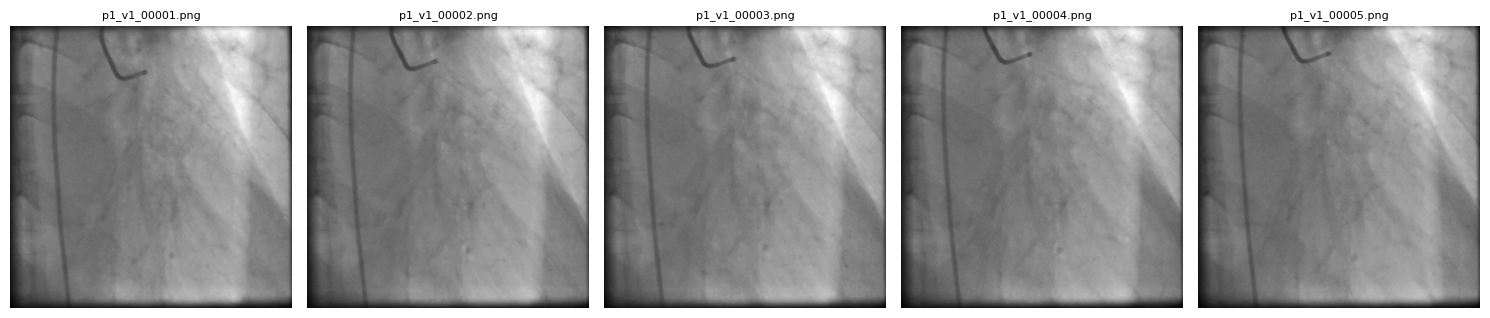

In [8]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(png_files), figsize=(15, 4))
if len(png_files) == 1:
    axes = [axes]

for ax, img_path in zip(axes, png_files):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
from pathlib import Path

video_dir = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v1")
input_dir = video_dir / "input"

# keyframe 목록 (있으면 이걸 써야 함!)
sf = list(video_dir.glob("*selectedFrames.txt"))
print("selectedFrames 파일:", sf)

if sf:
    with open(sf[0]) as f:
        frames = [line.strip() for line in f if line.strip()]
    print("선택된 프레임 수:", len(frames))
    print("예시:", frames[:10])

selectedFrames 파일: [PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v1/p1_v1_selectedFrames.txt')]
선택된 프레임 수: 27
예시: ['p1_v1_00026', 'p1_v1_00027', 'p1_v1_00028', 'p1_v1_00029', 'p1_v1_00030', 'p1_v1_00031', 'p1_v1_00032', 'p1_v1_00033', 'p1_v1_00034', 'p1_v1_00035']


In [10]:
p1_dir = Path("/content/cadica_dataset/CADICA/selectedVideos/p1")

print("=== lesion 영상 ===")
if (p1_dir / "lesionVideos.txt").exists():
    print((p1_dir / "lesionVideos.txt").read_text())

print("=== non-lesion 영상 ===")
if (p1_dir / "nonlesionVideos.txt").exists():
    print((p1_dir / "nonlesionVideos.txt").read_text())

=== lesion 영상 ===
v2
v3
v10
v11

=== non-lesion 영상 ===
v1
v4
v5
v6
v9
v12
v13
v14



총 프레임 수: 55


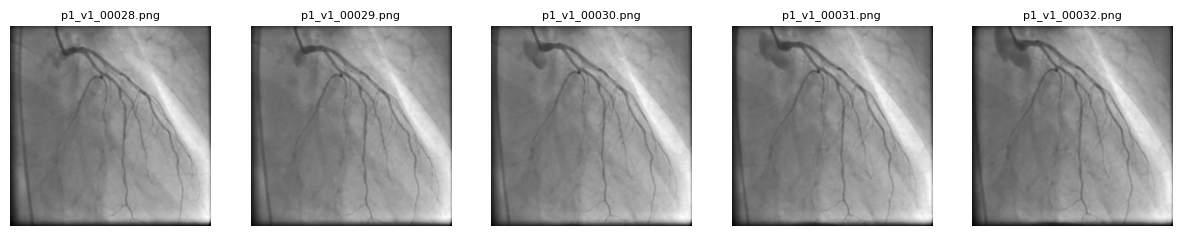

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

all_pngs = sorted(input_dir.glob("*.png"))
print("총 프레임 수:", len(all_pngs))

# 방법 A: 영상 중간~뒤쪽 샘플
sample_paths = all_pngs[len(all_pngs)//2 : len(all_pngs)//2 + 5]

# 방법 B: selectedFrames가 있으면 그걸로 (주석 해제)
# frame_ids = [int(x) for x in frames[:5]]
# sample_paths = [input_dir / f"p1_v1_{fid:05d}.png" for fid in frame_ids]

fig, axes = plt.subplots(1, len(sample_paths), figsize=(15, 4))
for ax, p in zip(axes, sample_paths):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(p.name, fontsize=8)
    ax.axis('off')
plt.show()

In [14]:
base = Path("/content/cadica_dataset/CADICA/selectedVideos")

for p_dir in sorted(base.glob("p*"))[:5]:
    lesion_file = p_dir / "lesionVideos.txt"
    if not lesion_file.exists():
        continue
    lesion_vids = lesion_file.read_text().strip().split()
    if not lesion_vids:
        continue

    v_name = lesion_vids[0].strip()   # 이미 "v2" 형태이므로 그대로 사용
    v_dir = p_dir / v_name

    if not v_dir.exists():
        print(f"{p_dir.name}/{v_name} | 폴더 없음 (경로 확인 필요)")
        continue

    gt_exists = (v_dir / "groundtruth").exists()
    input_dir = v_dir / "input"
    n_png = len(list(input_dir.glob("*.png"))) if input_dir.exists() else 0

    print(f"{p_dir.name}/{v_name} | png:{n_png} | groundtruth:{gt_exists}")

p1/v2 | png:56 | groundtruth:True
p10/v1 | png:51 | groundtruth:True
p11/v3 | png:51 | groundtruth:True
p12/v1 | png:49 | groundtruth:True
p13/v1 | png:52 | groundtruth:True


In [15]:
gt_dir = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth")
gt_files = sorted(gt_dir.glob("*.txt"))
print("라벨 파일 수:", len(gt_files))
print("예시:", gt_files[:3])

# 라벨 내용 확인 (bbox: x y w h category)
print(gt_files[0].read_text())

라벨 파일 수: 13
예시: [PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth/p1_v2_00015.txt'), PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth/p1_v2_00016.txt'), PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth/p1_v2_00017.txt')]
257 123 42 55 p0_20



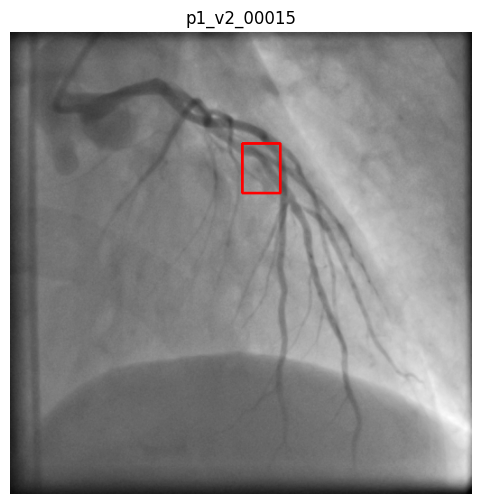

In [16]:
import re

sample_gt = gt_files[0]
frame_id = sample_gt.stem  # 예: "p1_v2_00023"
img_path = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/input") / f"{frame_id}.png"

img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(sample_gt) as f:
    for line in f:
        parts = line.strip().split()
        x, y, w, h = map(int, parts[:4])
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(frame_id)
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


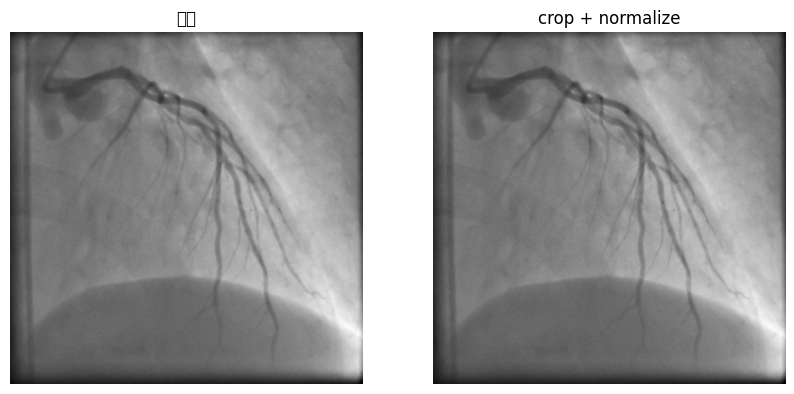

In [17]:
import numpy as np

def simple_preprocess(gray):
    # 1) 검은 여백 제거
    ys, xs = np.where(gray > 10)
    if len(xs) == 0:
        return gray
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    cropped = gray[y1:y2+1, x1:x2+1]

    # 2) 0~1 normalize
    cropped = cropped.astype(np.float32)
    cropped = (cropped - cropped.min()) / (cropped.max() - cropped.min() + 1e-8)
    return cropped

gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
proc = simple_preprocess(gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("원본")
axes[0].axis('off')

axes[1].imshow(proc, cmap='gray')
axes[1].set_title("crop + normalize")
axes[1].axis('off')
plt.show()

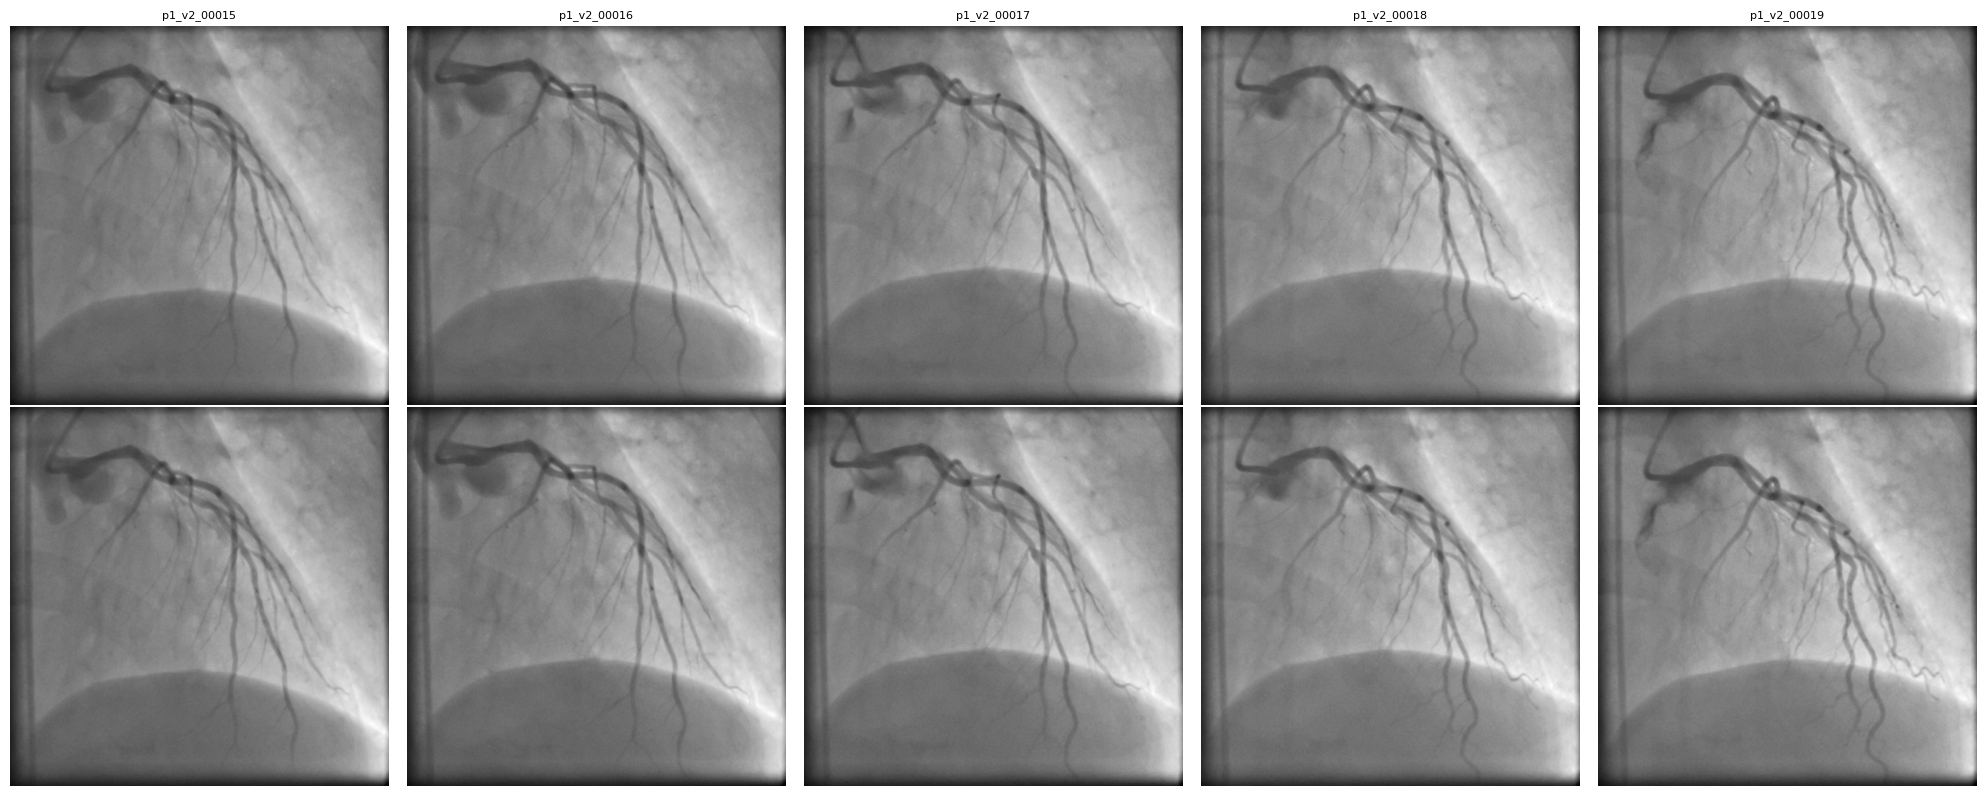

In [18]:
gt_files_5 = gt_files[:5]

fig, axes = plt.subplots(2, len(gt_files_5), figsize=(4*len(gt_files_5), 8))

for i, gt_file in enumerate(gt_files_5):
    fid = gt_file.stem
    ip = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/input") / f"{fid}.png"
    g = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
    p = simple_preprocess(g)

    axes[0, i].imshow(g, cmap='gray')
    axes[0, i].set_title(fid, fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(p, cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()